# CREATING FILES

## Creating baseline_dataset file

In [36]:
import pandas as pd
import numpy as np
import os

# ---------------------------
# Paths
# ---------------------------
final_data_path = r"C:\Users\jkgas\OneDrive\Desktop\data_science\Spring_2026\bachelor_project\data\final_data"

users_file = os.path.join(final_data_path, "users.csv")
user_games_file = os.path.join(final_data_path, "user_games.csv")
games_file = os.path.join(final_data_path, "games.csv")

baseline_output = os.path.join(final_data_path, "baseline_dataset.csv")

# ---------------------------
# Load data
# ---------------------------
users = pd.read_csv(users_file)
user_games = pd.read_csv(user_games_file)
games = pd.read_csv(games_file)

original_rows = len(user_games)

# ---------------------------
# Account age features
# ---------------------------
users["account_created"] = pd.to_datetime(
    users["account_created"], unit="s", errors="coerce"
)

now = pd.Timestamp.now()

users["account_age_minutes"] = (
    (now - users["account_created"]).dt.total_seconds() / 60
)

# Keep country for baseline
# ---------------------------
# Merge account age into interactions
# ---------------------------
user_games = user_games.merge(
    users[["steamid", "account_age_minutes", "country"]],
    on="steamid",
    how="left"
)

# ---------------------------
# Cap individual playtime
# ---------------------------
user_games["playtime_minutes_capped"] = np.minimum(
    user_games["playtime_minutes"],
    user_games["account_age_minutes"]
)

# ---------------------------
# USER AGGREGATE FEATURES
# ---------------------------
user_agg = user_games.groupby("steamid").agg(
    total_games_owned=("appid", "nunique"),
    total_playtime_minutes=("playtime_minutes_capped", "sum"),
    median_playtime_minutes=("playtime_minutes_capped", "median")
)

# Cap lifetime total_playtime by account age
user_agg = user_agg.join(users.set_index("steamid")["account_age_minutes"])
user_agg["total_playtime_minutes"] = np.minimum(
    user_agg["total_playtime_minutes"],
    user_agg["account_age_minutes"]
)
user_agg.drop(columns="account_age_minutes", inplace=True)

# ---------------------------
# UNIQUE GENRES PER USER
# ---------------------------
user_games_genres = user_games.merge(
    games[["appid", "genres"]],
    on="appid",
    how="left"
)

user_games_genres["genres"] = (
    user_games_genres["genres"]
    .fillna("")
    .str.split(";")
)

user_genres = (
    user_games_genres.explode("genres")
    .groupby("steamid")["genres"]
    .nunique()
    .rename("unique_genres_played")
)

user_agg = user_agg.join(user_genres)

# ---------------------------
# GAME FEATURES
# ---------------------------
games["release_date"] = pd.to_datetime(
    games["release_date"], errors="coerce"
)

game_agg = user_games.groupby("appid")["playtime_minutes_capped"] \
    .sum().rename("game_total_playtime_minutes")

games = games.set_index("appid").join(game_agg).reset_index()

# ---------------------------
# BUILD FINAL BASELINE DATASET
# ---------------------------
baseline = user_games.merge(
    user_agg.reset_index(),
    on="steamid",
    how="left"
)

baseline = baseline.merge(
    games,
    on="appid",
    how="left"
)

# ---------------------------
# DROP REDUNDANT COLUMNS
# ---------------------------
baseline = baseline.drop(columns=[
    "playtime_minutes",
    "account_age_minutes",
    "release_year",
    "playtime_minutes_capped"
], errors="ignore")

# ---------------------------
# Final checks
# ---------------------------
print("Original rows:", original_rows)
print("Baseline rows:", len(baseline))

print("\n===== BASELINE HEAD =====")
print(baseline.head())

print("\n===== BASELINE DESCRIBE =====")
print(baseline.describe(include="all"))

# ---------------------------
# Save baseline dataset
# ---------------------------
baseline.to_csv(baseline_output, index=False)
print("✅ Baseline dataset saved to:", baseline_output)

Original rows: 4010476
Baseline rows: 4010476

===== BASELINE HEAD =====
             steamid  appid country  total_games_owned  \
0  76561198064675174    400      IT                170   
1  76561198064675174    500      IT                170   
2  76561198064675174    550      IT                170   
3  76561198064675174    620      IT                170   
4  76561198064675174   3900      IT                170   

   total_playtime_minutes  median_playtime_minutes  unique_genres_played  \
0                505414.0                    588.0                    15   
1                505414.0                    588.0                    15   
2                505414.0                    588.0                    15   
3                505414.0                    588.0                    15   
4                505414.0                    588.0                    15   

                           name            genres      developer publisher  \
0                        Portal            

In [2]:
import pandas as pd

baseline_path = r"C:\Users\jkgas\OneDrive\Desktop\data_science\Spring_2026\bachelor_project\data\baseline\baseline_dataset.csv"

baseline = pd.read_csv(baseline_path)

print("Loaded:", baseline.shape)

Loaded: (4010476, 15)


In [3]:
numeric_cols = [
    "total_games_owned",
    "total_playtime_minutes",
    "median_playtime_minutes",
    "unique_genres_played",
    "user_count",
    "game_total_playtime_minutes"
]

corr = baseline[numeric_cols].corr()

print(corr.round(2))

                             total_games_owned  total_playtime_minutes  \
total_games_owned                         1.00                    0.38   
total_playtime_minutes                    0.38                    1.00   
median_playtime_minutes                  -0.02                    0.04   
unique_genres_played                      0.75                    0.36   
user_count                               -0.25                   -0.13   
game_total_playtime_minutes              -0.06                   -0.04   

                             median_playtime_minutes  unique_genres_played  \
total_games_owned                              -0.02                  0.75   
total_playtime_minutes                          0.04                  0.36   
median_playtime_minutes                         1.00                 -0.05   
unique_genres_played                           -0.05                  1.00   
user_count                                      0.06                 -0.36   
game_total_pl

## Creating baseline_small file

In [5]:
import pandas as pd
import numpy as np

SEED = 42
np.random.seed(SEED)

baseline_path = r"C:\Users\jkgas\OneDrive\Desktop\data_science\Spring_2026\bachelor_project\data\baseline\baseline_dataset.csv"

df = pd.read_csv(baseline_path)

# ------------------
# SAMPLE USERS
# ------------------
n_users = 1000

sampled_users = np.random.choice(
    df["steamid"].unique(),
    size=n_users,
    replace=False
)

df_small = df[df["steamid"].isin(sampled_users)]

print("Users:", df_small["steamid"].nunique())
print("Rows:", len(df_small))

df_small.to_csv("baseline_small.csv", index=False)

Users: 1000
Rows: 133207


## Creating network_feat_dataset file

In [6]:
import pandas as pd
import numpy as np
import os

# ---------------------------
# Paths
# ---------------------------
data_path = r"D:\bachelor_project\ml\network_feat_dataset.csv"

df = pd.read_csv(data_path)
pd.set_option('display.max_columns', None)
num_rows = len(df)
print(num_rows)
print(df.head(10))

4010476
             steamid  appid country  total_games_owned  \
0  76561198064675174    400      IT                170   
1  76561198064675174    500      IT                170   
2  76561198064675174    550      IT                170   
3  76561198064675174    620      IT                170   
4  76561198064675174   3900      IT                170   
5  76561198064675174   3910      IT                170   
6  76561198064675174   7650      IT                170   
7  76561198064675174   7660      IT                170   
8  76561198064675174   7670      IT                170   
9  76561198064675174   7730      IT                170   

   total_playtime_minutes  median_playtime_minutes  unique_genres_played  \
0                505414.0                    588.0                    15   
1                505414.0                    588.0                    15   
2                505414.0                    588.0                    15   
3                505414.0                    588.

In [5]:
import pandas as pd
import os

# ---------------------------
# Load data
# ---------------------------
data_path = r"D:\bachelor_project\ml\dataset_merged_baseline_pca_thr99_friends.csv"
df = pd.read_csv(data_path)

# ---------------------------
# 1. Remove game_index
# ---------------------------
df = df.drop(columns=["game_index"])

# ---------------------------
# 2. Move friend_count after unique_genres_played
# ---------------------------
cols = df.columns.tolist()

# remove friend_count temporarily
cols.remove("friend_count")

# find position of unique_genres_played
insert_pos = cols.index("unique_genres_played") + 1

# insert friend_count after it
cols.insert(insert_pos, "friend_count")

# reorder dataframe
df = df[cols]

# ---------------------------
# 3. Save in same directory
# ---------------------------
output_path = os.path.join(
    os.path.dirname(data_path),
    "network_feat_dataset.csv"
)

df.to_csv(output_path, index=False)

print(f"Saved to: {output_path}")

Saved to: D:\bachelor_project\ml\network_feat_dataset.csv


## Creating network_feat_small file

In [7]:
import pandas as pd
import numpy as np

SEED = 42
np.random.seed(SEED)

baseline_path = r"D:\bachelor_project\ml\network_feat_dataset.csv"

df = pd.read_csv(baseline_path)

# ------------------
# SAMPLE USERS
# ------------------
n_users = 1000

sampled_users = np.random.choice(
    df["steamid"].unique(),
    size=n_users,
    replace=False
)

df_small = df[df["steamid"].isin(sampled_users)]

print("Users:", df_small["steamid"].nunique())
print("Rows:", len(df_small))

df_small.to_csv("network_feat_small.csv", index=False)

Users: 1000
Rows: 133207


### Standarization and PCA on games-similarity matrix

Loading matrix...
Matrix shape: (20988, 20988)
First 5x5 block:
 [[   0.      3044.4028  2602.1     2589.407   3096.4314 ]
 [   0.         0.       868.38324  842.5616   203.53499]
 [   0.         0.         0.        69.28137  983.63904]
 [   0.         0.         0.         0.       952.70447]
 [   0.         0.         0.         0.         0.     ]]

Running TEST MODE with size 500 x 500
Small matrix shape: (500, 500)

Reconstructing symmetric matrix...
Symmetric matrix created.

Sanity checks (before normalization):
Any NaNs? 0
Min value: 0.0
Max value: 7152.5093
Matrix symmetric check: True

Applying log1p normalization...
After log normalization:
Min value: 0.0
Max value: 8.875359

Standardizing features...
Scaled matrix mean (should be ~0): -5.126953e-09
Scaled matrix std (should be ~1): 1.0

Fitting PCA...

Variance threshold: 0.9
Optimal number of components: 50
Achieved variance: 0.9003
Final embedding shape: (500, 50)

Sanity checks (after PCA):
Any NaNs? 0
Embedding mean (

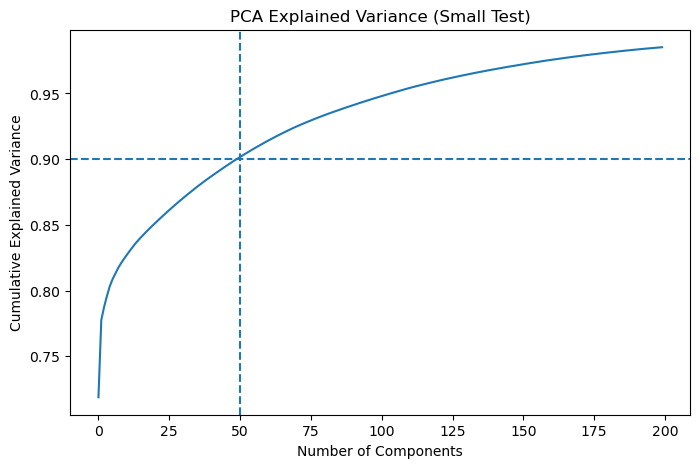


Embeddings saved to game_pca_embeddings_small_test.csv


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ======================================
# SETTINGS
# ======================================

FILE_PATH = r"D:\bachelor_project\micheles_algorithm\new_version\game_game_dists_sq_20988.mmap"

TEST_SIZE = 500                # Try 500 first (can increase to 1000)
USE_LOG = True
VARIANCE_THRESHOLD = 0.90
MAX_COMPONENTS = 200           # Safety cap for PCA

# ======================================
# 1️⃣ LOAD UPPER TRIANGLE MATRIX
# ======================================

print("Loading matrix...")
matrix = np.memmap(FILE_PATH, dtype=np.float32, mode='r', shape=(20988, 20988))

print("Matrix shape:", matrix.shape)
print("First 5x5 block:\n", matrix[:5, :5])

# ======================================
# 2️⃣ CREATE SMALL SAMPLE
# ======================================

print(f"\nRunning TEST MODE with size {TEST_SIZE} x {TEST_SIZE}")
upper_small = matrix[:TEST_SIZE, :TEST_SIZE]

print("Small matrix shape:", upper_small.shape)

# ======================================
# 3️⃣ RECONSTRUCT SYMMETRIC MATRIX
# ======================================

print("\nReconstructing symmetric matrix...")
S = upper_small + upper_small.T

# Remove doubled diagonal
np.fill_diagonal(S, 0)

print("Symmetric matrix created.")

# ======================================
# 4️⃣ SANITY CHECKS (BEFORE NORMALIZATION)
# ======================================

print("\nSanity checks (before normalization):")
print("Any NaNs?", np.isnan(S).sum())
print("Min value:", np.min(S))
print("Max value:", np.max(S))
print("Matrix symmetric check:", np.allclose(S, S.T))

# ======================================
# 5️⃣ OPTIONAL LOG NORMALIZATION
# ======================================

if USE_LOG:
    print("\nApplying log1p normalization...")
    S = np.log1p(S)

    print("After log normalization:")
    print("Min value:", np.min(S))
    print("Max value:", np.max(S))

# ======================================
# 6️⃣ STANDARDIZE FOR PCA
# ======================================

print("\nStandardizing features...")
scaler = StandardScaler()
S_scaled = scaler.fit_transform(S)

print("Scaled matrix mean (should be ~0):", np.mean(S_scaled))
print("Scaled matrix std (should be ~1):", np.std(S_scaled))

# ======================================
# 7️⃣ PCA
# ======================================

print("\nFitting PCA...")

pca = PCA(
    n_components=min(MAX_COMPONENTS, TEST_SIZE),
    svd_solver='randomized',
    random_state=42
)

S_reduced_full = pca.fit_transform(S_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

# ======================================
# 8️⃣ AUTOMATIC COMPONENT SELECTION
# ======================================

optimal_components = np.argmax(cumulative >= VARIANCE_THRESHOLD) + 1

print(f"\nVariance threshold: {VARIANCE_THRESHOLD}")
print(f"Optimal number of components: {optimal_components}")
print(f"Achieved variance: {cumulative[optimal_components - 1]:.4f}")

game_embeddings = S_reduced_full[:, :optimal_components]

print("Final embedding shape:", game_embeddings.shape)

# ======================================
# 9️⃣ SANITY CHECKS AFTER PCA
# ======================================

print("\nSanity checks (after PCA):")
print("Any NaNs?", np.isnan(game_embeddings).sum())
print("Embedding mean (should be ~0):", np.mean(game_embeddings))
print("Embedding std:", np.std(game_embeddings))

# ======================================
# 🔟 SCREE PLOT
# ======================================

plt.figure(figsize=(8,5))
plt.plot(cumulative)
plt.axhline(y=VARIANCE_THRESHOLD, linestyle='--')
plt.axvline(x=optimal_components, linestyle='--')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance (Small Test)")
plt.show()

# ======================================
# 11️⃣ SAVE SMALL TEST EMBEDDINGS
# ======================================

embedding_df = pd.DataFrame(
    game_embeddings,
    columns=[f"game_emb_{i}" for i in range(optimal_components)]
)

embedding_df["game_index"] = embedding_df.index

embedding_df.to_csv("game_pca_embeddings_small_test.csv", index=False)

print("\nEmbeddings saved to game_pca_embeddings_small_test.csv")

Loading matrix...
Matrix loaded.
Shape: (20988, 20988)


RUN 1/5
Sampled indices (first 10): [ 57 112 131 166 173 205 305 332 340 346]
Submatrix shape: (500, 500)
Symmetric check: True
Log normalization applied.
Scaled mean: 1.171875e-08
Scaled std: 1.0
Optimal components: 3
Achieved variance: 0.9059


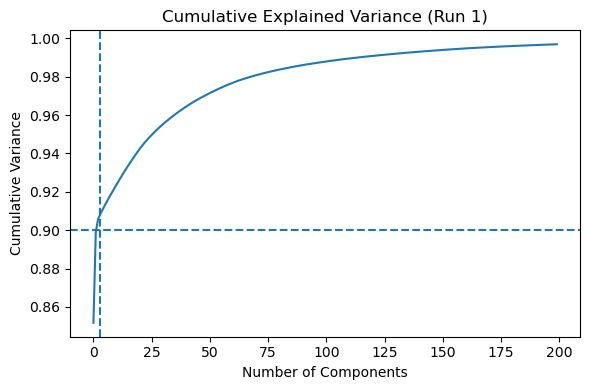


RUN 2/5
Sampled indices (first 10): [121 147 233 282 310 345 346 415 428 463]
Submatrix shape: (500, 500)
Symmetric check: True
Log normalization applied.
Scaled mean: 4.8828124e-09
Scaled std: 0.99999994
Optimal components: 3
Achieved variance: 0.9005


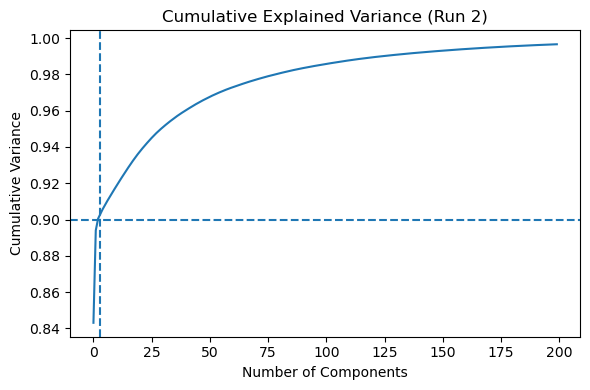


RUN 3/5
Sampled indices (first 10): [ 48  65  69 141 204 241 267 288 415 437]
Submatrix shape: (500, 500)
Symmetric check: True
Log normalization applied.
Scaled mean: -1.953125e-08
Scaled std: 1.0
Optimal components: 2
Achieved variance: 0.9098


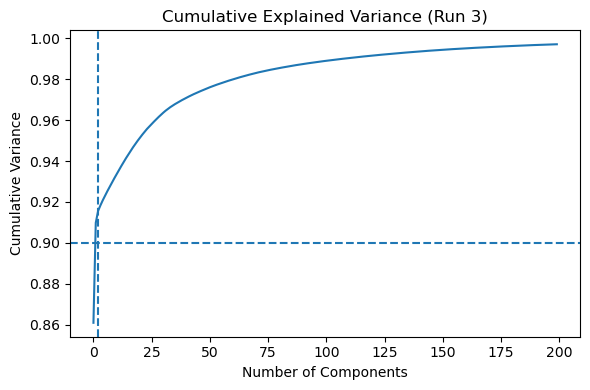


RUN 4/5
Sampled indices (first 10): [ 23  31  98 172 185 239 251 407 497 536]
Submatrix shape: (500, 500)
Symmetric check: True
Log normalization applied.
Scaled mean: -3.125e-08
Scaled std: 1.0
Optimal components: 3
Achieved variance: 0.9050


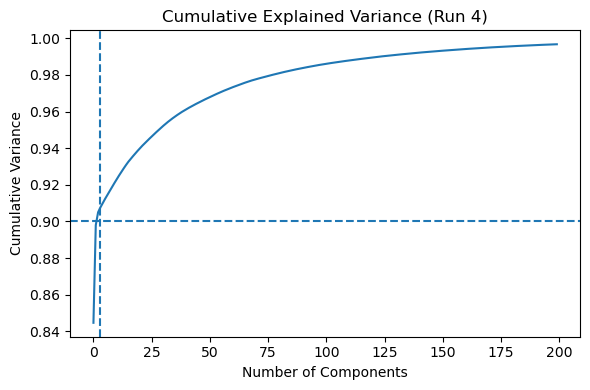


RUN 5/5
Sampled indices (first 10): [ 40  85  89 157 170 189 276 290 362 403]
Submatrix shape: (500, 500)
Symmetric check: True
Log normalization applied.
Scaled mean: -9.765625e-10
Scaled std: 1.0000001
Optimal components: 5
Achieved variance: 0.9004


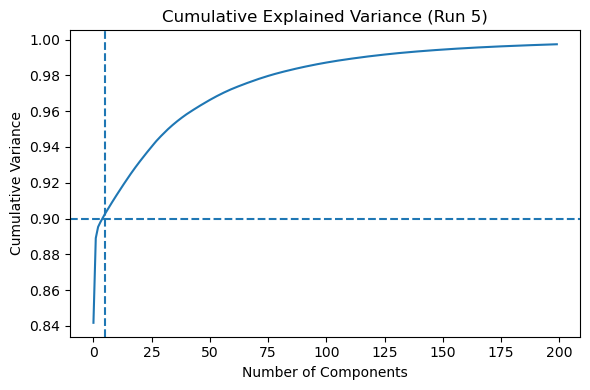


FINAL SUMMARY
Optimal components across runs: [3, 3, 2, 3, 5]
Mean: 3.2
Std: 0.9797958971132712
Min: 2
Max: 5


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ======================================
# SETTINGS
# ======================================

FILE_PATH = r"D:\bachelor_project\micheles_algorithm\new_version\game_game_dists_sq_20988.mmap"

N_TOTAL = 20988
TEST_SIZE = 500
N_RUNS = 5

USE_LOG = True
VARIANCE_THRESHOLD = 0.90
MAX_COMPONENTS = 200

# ======================================
# 1️⃣ LOAD MATRIX
# ======================================

print("Loading matrix...")
matrix = np.memmap(
    FILE_PATH,
    dtype=np.float32,
    mode='r',
    shape=(N_TOTAL, N_TOTAL)
)

print("Matrix loaded.")
print("Shape:", matrix.shape)
print()

# ======================================
# 🔁 RANDOM SAMPLING EXPERIMENT
# ======================================

results = []

for run in range(N_RUNS):

    print("\n" + "="*60)
    print(f"RUN {run+1}/{N_RUNS}")
    print("="*60)

    # -------------------------------
    # 2️⃣ Randomly sample indices
    # -------------------------------
    rng = np.random.default_rng(seed=run)
    random_indices = rng.choice(N_TOTAL, size=TEST_SIZE, replace=False)
    random_indices.sort()

    print("Sampled indices (first 10):", random_indices[:10])

    # -------------------------------
    # 3️⃣ Extract submatrix
    # -------------------------------
    upper_small = matrix[np.ix_(random_indices, random_indices)]
    print("Submatrix shape:", upper_small.shape)

    # -------------------------------
    # 4️⃣ Reconstruct symmetric matrix
    # -------------------------------
    S = upper_small + upper_small.T
    np.fill_diagonal(S, 0)

    print("Symmetric check:", np.allclose(S, S.T))

    # -------------------------------
    # 5️⃣ Log normalization
    # -------------------------------
    if USE_LOG:
        S = np.log1p(S)
        print("Log normalization applied.")

    # -------------------------------
    # 6️⃣ Standardize
    # -------------------------------
    scaler = StandardScaler()
    S_scaled = scaler.fit_transform(S)

    print("Scaled mean:", np.mean(S_scaled))
    print("Scaled std:", np.std(S_scaled))

    # -------------------------------
    # 7️⃣ PCA
    # -------------------------------
    pca = PCA(
        n_components=min(MAX_COMPONENTS, TEST_SIZE),
        svd_solver='randomized',
        random_state=42
    )

    S_reduced_full = pca.fit_transform(S_scaled)

    explained = pca.explained_variance_ratio_
    cumulative = np.cumsum(explained)

    # -------------------------------
    # 8️⃣ Optimal components
    # -------------------------------
    optimal_components = np.argmax(cumulative >= VARIANCE_THRESHOLD) + 1

    print(f"Optimal components: {optimal_components}")
    print(f"Achieved variance: {cumulative[optimal_components - 1]:.4f}")

    results.append(optimal_components)

    # -------------------------------
    # 9️⃣ Scree plot
    # -------------------------------
    plt.figure(figsize=(6,4))
    plt.plot(cumulative)
    plt.axhline(y=VARIANCE_THRESHOLD, linestyle='--')
    plt.axvline(x=optimal_components, linestyle='--')
    plt.title(f"Cumulative Explained Variance (Run {run+1})")
    plt.xlabel("Number of Components")
    plt.ylabel("Cumulative Variance")
    plt.tight_layout()
    plt.show()

# ======================================
# 🔟 FINAL SUMMARY
# ======================================

print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

print("Optimal components across runs:", results)
print("Mean:", np.mean(results))
print("Std:", np.std(results))
print("Min:", np.min(results))
print("Max:", np.max(results))

### Joining features

In [11]:
import pandas as pd

# File path
file_path = r"D:\bachelor_project\data_for_ml\network_feat_dataset.csv"

# Load CSV
df = pd.read_csv(file_path)

# Show all columns
pd.set_option('display.max_columns', None)  # None = no limit
pd.set_option('display.width', 200)         # widen console view if needed

# Print the entire dataframe (or first N rows if large)
print(df.head(10))  # prints first 20 rows
print(df.info())
print(df.describe())
print(len(df))

             steamid  appid country  total_games_owned  total_playtime_minutes  median_playtime_minutes  unique_genres_played  friend_count                                    name            genres  \
0  76561198064675174    400      IT                170                505414.0                    588.0                    15            28                                  Portal            Action   
1  76561198064675174    500      IT                170                505414.0                    588.0                    15            28                             Left 4 Dead            Action   
2  76561198064675174    550      IT                170                505414.0                    588.0                    15            28                           Left 4 Dead 2            Action   
3  76561198064675174    620      IT                170                505414.0                    588.0                    15            28                                Portal 2  Action;Adventur

# MACHINE LEARNING

## Naive classifier

In [2]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

SEED = 42
np.random.seed(SEED)

DATA_FILE = r"C:\Users\jkgas\OneDrive\Desktop\data_science\Spring_2026\bachelor_project\data\baseline\baseline_dataset.csv"
TEST_FRAC_PER_USER = 0.2

print(f"Loading: {DATA_FILE}")
df = pd.read_csv(DATA_FILE)

print("Original shape:", df.shape)
print("Unique users:", df["steamid"].nunique())
print("Unique games:", df["appid"].nunique())

# -----------------------------
# PREPARE POSITIVES
# -----------------------------
positives = df[['steamid', 'appid']].drop_duplicates()
positives["owned"] = 1

all_games = np.array(sorted(df["appid"].unique()))
user_owned = positives.groupby("steamid")["appid"].apply(lambda s: np.array(s.values)).to_dict()

train_pairs, test_pairs = [], []
neg_train_pairs, neg_test_pairs = [], []

print("Building per-user train/test with negative sampling...")

for user, owned_games in tqdm(user_owned.items(), desc="Users"):

    owned_games = np.unique(owned_games)

    # ---- SPLIT POSITIVES ----
    if len(owned_games) < 2:
        pos_train = owned_games
        pos_test = np.array([], dtype=owned_games.dtype)
    else:
        rng = np.random.default_rng(SEED + int(user) % 100000)
        shuffled = owned_games.copy()
        rng.shuffle(shuffled)

        n_test = max(1, int(np.ceil(TEST_FRAC_PER_USER * len(shuffled))))
        pos_test = shuffled[:n_test]
        pos_train = shuffled[n_test:]

    train_pairs.extend([(user, g, 1) for g in pos_train])
    test_pairs.extend([(user, g, 1) for g in pos_test])

    # ---- NEGATIVE SAMPLING ----
    not_owned = all_games[~np.isin(all_games, owned_games)]

    if len(not_owned) == 0:
        continue

    n_neg_train = len(pos_train)
    n_neg_test = len(pos_test)

    # sample test negatives first
    if n_neg_test > 0:
        replace_test = len(not_owned) < n_neg_test
        neg_test = np.random.choice(not_owned, size=n_neg_test, replace=replace_test)
        neg_test_set = set(neg_test)
    else:
        neg_test = np.array([], dtype=not_owned.dtype)
        neg_test_set = set()

    # sample train negatives excluding test negatives
    train_pool = np.array([g for g in not_owned if g not in neg_test_set])
    if len(train_pool) == 0:
        train_pool = not_owned

    if n_neg_train > 0:
        replace_train = len(train_pool) < n_neg_train
        neg_train = np.random.choice(train_pool, size=n_neg_train, replace=replace_train)
    else:
        neg_train = np.array([], dtype=not_owned.dtype)

    neg_train_pairs.extend([(user, g, 0) for g in neg_train])
    neg_test_pairs.extend([(user, g, 0) for g in neg_test])


# -----------------------------
# BUILD FINAL TRAIN / TEST
# -----------------------------
train_df = pd.DataFrame(train_pairs + neg_train_pairs, columns=["steamid", "appid", "owned"])
test_df  = pd.DataFrame(test_pairs  + neg_test_pairs,  columns=["steamid", "appid", "owned"])

train_df = train_df.drop_duplicates(["steamid","appid"]).reset_index(drop=True)
test_df  = test_df.drop_duplicates(["steamid","appid"]).reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("Train positives:", train_df["owned"].sum(),
      "negatives:", (train_df["owned"]==0).sum())
print("Test positives:", test_df["owned"].sum(),
      "negatives:", (test_df["owned"]==0).sum())


# ============================================================
# NAIVE POPULARITY CLASSIFIER
# ============================================================

top_N_values = [1, 5, 10, 20, 50]

print("\nNaive Popularity Baseline Results\n")

for N in top_N_values:

    # IMPORTANT: use TRAIN ONLY to determine popularity
    top_games = (
        train_df[train_df["owned"] == 1]["appid"]
        .value_counts()
        .head(N)
        .index
        .tolist()
    )

    # Predict on TEST
    test_pred = test_df["appid"].apply(lambda x: 1 if x in top_games else 0)

    acc = accuracy_score(test_df["owned"], test_pred)
    prec = precision_score(test_df["owned"], test_pred)
    rec = recall_score(test_df["owned"], test_pred)
    f1 = f1_score(test_df["owned"], test_pred)
    roc = roc_auc_score(test_df["owned"], test_pred)
    cm = confusion_matrix(test_df["owned"], test_pred)

    print(f"Top {N} games")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc:.4f}")
    print("Confusion Matrix:\n", cm)
    print("-" * 40)

print("DONE.")

Loading: C:\Users\jkgas\OneDrive\Desktop\data_science\Spring_2026\bachelor_project\data\baseline\baseline_dataset.csv
Original shape: (4010476, 15)
Unique users: 31021
Unique games: 20918
Building per-user train/test with negative sampling...


Users: 100%|█████████████████████████████████████████████████████████████████████| 31021/31021 [07:30<00:00, 68.88it/s]


Train shape: (6336589, 3)
Test shape: (1624645, 3)
Train positives: 3196470 negatives: 3140119
Test positives: 814006 negatives: 810639

Naive Popularity Baseline Results

Top 1 games
Accuracy:  0.5022
Precision: 0.9983
Recall:    0.0065
F1 Score:  0.0128
ROC-AUC:   0.5032
Confusion Matrix:
 [[810630      9]
 [808746   5260]]
----------------------------------------
Top 5 games
Accuracy:  0.5098
Precision: 0.9969
Recall:    0.0217
F1 Score:  0.0424
ROC-AUC:   0.5108
Confusion Matrix:
 [[810585     54]
 [796359  17647]]
----------------------------------------
Top 10 games
Accuracy:  0.5173
Precision: 0.9957
Recall:    0.0368
F1 Score:  0.0710
ROC-AUC:   0.5183
Confusion Matrix:
 [[810509    130]
 [784051  29955]]
----------------------------------------
Top 20 games
Accuracy:  0.5301
Precision: 0.9952
Recall:    0.0625
F1 Score:  0.1176
ROC-AUC:   0.5311
Confusion Matrix:
 [[810396    243]
 [763122  50884]]
----------------------------------------
Top 50 games
Accuracy:  0.5589
Precisi

## ML for baseline

### Training and testing

Original shape: (133207, 15)
Unique users: 1000
Unique games: 18832


Users: 100%|███████████████████████████████████████████████████████████████████████| 1000/1000 [00:18<00:00, 54.29it/s]



Model: LogisticRegression
Accuracy: 0.8520508195435652
Precision: 0.8508721349286436
Recall: 0.8738618698645347
F1 Score: 0.8622137822736734
ROC AUC: 0.914479274796201
Confusion Matrix:
 [[19848  4138]
 [ 3408 23610]]
[learning_curve] Training set sizes: [ 13227  42989  72751 102513 132276]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of  15 | elapsed:   11.6s remaining:   32.0s
[Parallel(n_jobs=-1)]: Done  10 out of  15 | elapsed:   17.7s remaining:    8.8s
[Parallel(n_jobs=-1)]: Done  15 out of  15 | elapsed:   24.9s finished


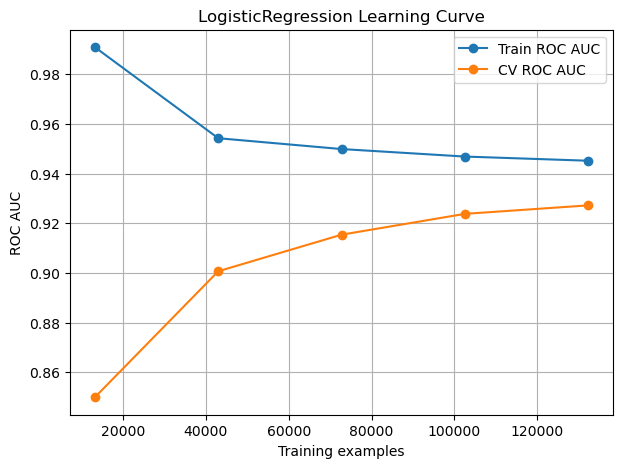

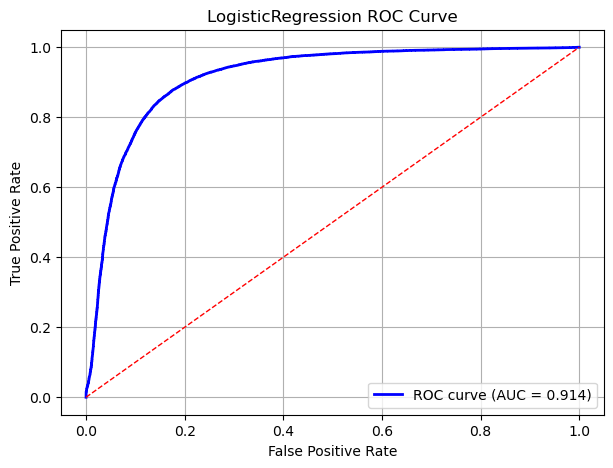


Model: RandomForest


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    0.2s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   6 out of  10 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=8)]: Done  10 out of  10 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   6 out of  10 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=8)]: Done  10 out of  10 | elapsed:    0.0s finished


Accuracy: 0.5369970982668026
Precision: 0.5336697338478282
Recall: 0.9981863942556815
F1 Score: 0.695498562273542
ROC AUC: 0.6441362484026556
Confusion Matrix:
 [[  420 23566]
 [   49 26969]]
[learning_curve] Training set sizes: [ 13227  42989  72751 102513 132276]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of  15 | elapsed:    4.4s remaining:   12.4s
[Parallel(n_jobs=-1)]: Done  10 out of  15 | elapsed:    6.8s remaining:    3.4s
[Parallel(n_jobs=-1)]: Done  15 out of  15 | elapsed:    9.6s finished


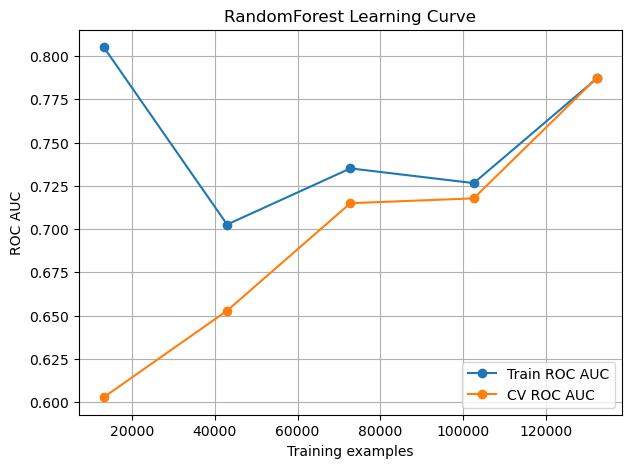

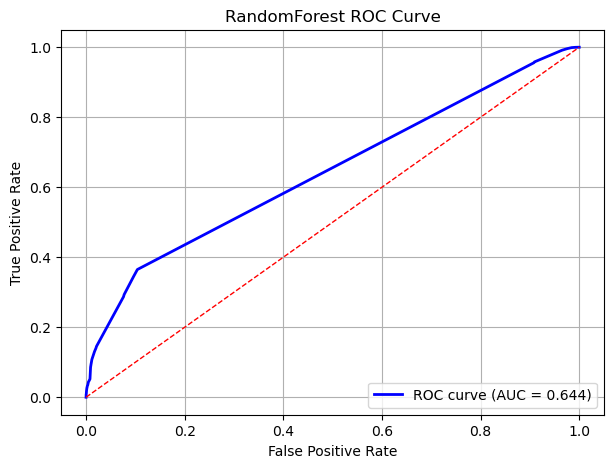


Model: XGBoost
Accuracy: 0.8443847541369305
Precision: 0.8348131251096683
Recall: 0.8804500703234881
F1 Score: 0.8570244807522562
ROC AUC: 0.9144880217558745
Confusion Matrix:
 [[19279  4707]
 [ 3230 23788]]
[learning_curve] Training set sizes: [ 13227  42989  72751 102513 132276]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 out of  15 | elapsed:   10.2s remaining:   28.3s
[Parallel(n_jobs=-1)]: Done  10 out of  15 | elapsed:   16.2s remaining:    8.0s
[Parallel(n_jobs=-1)]: Done  15 out of  15 | elapsed:   23.7s finished


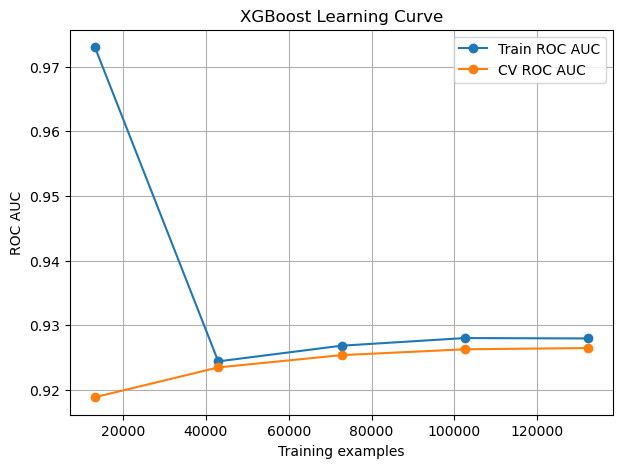

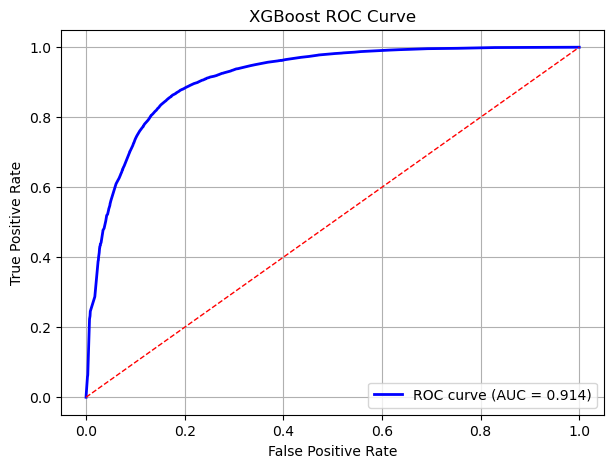

In [8]:
import os
import json
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# =========================================================
# SETTINGS
# =========================================================
SEED = 42
np.random.seed(SEED)

TEST_FRAC_PER_USER = 0.2
CV_SPLITS = 3

file = r"C:\Users\jkgas\OneDrive\Desktop\data_science\Spring_2026\bachelor_project\data\baseline\baseline_small.csv"

# =========================================================
# LOAD DATA
# =========================================================
df = pd.read_csv(file, sep=",", quotechar='"')
print("Original shape:", df.shape)
print("Unique users:", df["steamid"].nunique())
print("Unique games:", df["appid"].nunique())

# =========================================================
# USER & GAME FEATURES
# =========================================================
users_features = df[['steamid', 'country', 'total_games_owned',
                     'total_playtime_minutes', 'median_playtime_minutes',
                     'unique_genres_played', 'user_count']].drop_duplicates('steamid')

games_features = df[['appid', 'name', 'genres', 'developer',
                     'publisher', 'platforms', 'release_date',
                     'game_total_playtime_minutes']].drop_duplicates('appid')

positives = df[['steamid', 'appid']].drop_duplicates()
positives["owned"] = 1

all_games = np.array(sorted(df["appid"].unique()))
user_owned = positives.groupby("steamid")["appid"].apply(lambda s: np.array(s.values)).to_dict()

# =========================================================
# BUILD TRAIN / TEST WITH NEGATIVE SAMPLING
# =========================================================
train_pairs, test_pairs = [], []

for user, owned_games in tqdm(user_owned.items(), desc="Users"):

    owned_games = np.unique(owned_games)
    rng = np.random.default_rng(SEED + int(user) % 100000)

    if len(owned_games) < 2:
        pos_train = owned_games
        pos_test = np.array([], dtype=owned_games.dtype)
    else:
        shuffled = owned_games.copy()
        rng.shuffle(shuffled)
        n_test = max(1, int(np.ceil(TEST_FRAC_PER_USER * len(shuffled))))
        pos_test = shuffled[:n_test]
        pos_train = shuffled[n_test:]

    train_pairs.extend([(user, g, 1) for g in pos_train])
    test_pairs.extend([(user, g, 1) for g in pos_test])

    not_owned = all_games[~np.isin(all_games, owned_games)]
    if len(not_owned) == 0:
        continue

    n_neg_train = len(pos_train)
    n_neg_test = len(pos_test)

    if n_neg_test > 0:
        replace_test = len(not_owned) < n_neg_test
        neg_test = rng.choice(not_owned, size=n_neg_test, replace=replace_test)
        neg_test_set = set(map(int, neg_test))
    else:
        neg_test = np.array([], dtype=not_owned.dtype)
        neg_test_set = set()

    train_pool = np.array([g for g in not_owned if int(g) not in neg_test_set])
    if len(train_pool) == 0:
        train_pool = not_owned

    if n_neg_train > 0:
        replace_train = len(train_pool) < n_neg_train
        neg_train = rng.choice(train_pool, size=n_neg_train, replace=replace_train)
    else:
        neg_train = np.array([], dtype=not_owned.dtype)

    train_pairs.extend([(user, g, 0) for g in neg_train])
    test_pairs.extend([(user, g, 0) for g in neg_test])

train_df = pd.DataFrame(train_pairs, columns=["steamid","appid","owned"]).drop_duplicates(["steamid","appid"]).reset_index(drop=True)
test_df = pd.DataFrame(test_pairs, columns=["steamid","appid","owned"]).drop_duplicates(["steamid","appid"]).reset_index(drop=True)

# =========================================================
# ATTACH FEATURES
# =========================================================
train_all = train_df.merge(users_features, on="steamid", how="left").merge(games_features, on="appid", how="left")
test_all = test_df.merge(users_features, on="steamid", how="left").merge(games_features, on="appid", how="left")

# =========================================================
# FEATURE SET
# =========================================================
numeric_features = [
    "total_games_owned","total_playtime_minutes","median_playtime_minutes",
    "unique_genres_played","user_count","game_total_playtime_minutes"
]

categorical_features = [
    "country","developer","publisher","platforms","genres"
]

target = "owned"

X_train = train_all[numeric_features + categorical_features].copy()
y_train = train_all[target].astype(int)
X_test = test_all[numeric_features + categorical_features].copy()
y_test = test_all[target].astype(int)

# =========================================================
# MISSING VALUE POLICY B
# =========================================================
missing_flags = []

for c in numeric_features:
    flag = c + "_is_missing"
    missing_flags.append(flag)

    X_train[flag] = X_train[c].isna().astype("int8")
    X_test[flag] = X_test[c].isna().astype("int8")

    med = float(X_train[c].median(skipna=True))
    X_train[c] = X_train[c].fillna(med).astype(np.float32)
    X_test[c] = X_test[c].fillna(med).astype(np.float32)

for c in categorical_features:
    X_train[c] = X_train[c].fillna("MISSING").astype(str)
    X_test[c] = X_test[c].fillna("MISSING").astype(str)

# =========================================================
# PREPROCESSOR
# =========================================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("miss", "passthrough", missing_flags),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

# =========================================================
# MODELS
# =========================================================
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=SEED, n_jobs=-1),
    "RandomForest": RandomForestClassifier(n_estimators=10, max_depth=5, min_samples_leaf=2, random_state=SEED, n_jobs=-1, verbose=1),
    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=SEED,
        n_estimators=10,
        learning_rate=0.05,
        tree_method="hist",
        n_jobs=-1,
        verbosity=1
    )
}

# =========================================================
# TRAIN, EVALUATE, LEARNING & ROC CURVES
# =========================================================
for name, model in models.items():
    print(f"\n==============================")
    print(f"Model: {name}")
    print(f"==============================")

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Train
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    # Metrics
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall:", recall_score(y_test, y_pred, zero_division=0))
    print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))
    print("ROC AUC:", roc_auc_score(y_test, y_proba))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    # Learning curve with progress bar
    train_sizes, train_scores, test_scores = learning_curve(
        pipe, X_train, y_train,
        cv=StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=SEED),
        scoring="roc_auc",
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1,
        verbose=3
    )

    plt.figure(figsize=(7,5))
    plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Train ROC AUC")
    plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label="CV ROC AUC")
    plt.title(f"{name} Learning Curve")
    plt.xlabel("Training examples")
    plt.ylabel("ROC AUC")
    plt.grid(True)
    plt.legend()
    plt.show()

    # ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7,5))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0,1], [0,1], color='red', lw=1, linestyle='--')
    plt.title(f"{name} ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(True)
    plt.legend(loc="lower right")
    plt.show()

### Checking features importance

In [26]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier

# ---------------- PARAMETERS ----------------
SEED = 42
TEST_FRAC_PER_USER = 0.2
SAMPLE_SIZE = 30  # small sample for testing

# ---------------- LOAD DATA ----------------
DATA_FILE = r"C:\Users\jkgas\OneDrive\Desktop\data_science\Spring_2026\bachelor_project\data\baseline\baseline_small.csv"
print(f"Loading dataset: {DATA_FILE}")
df = pd.read_csv(DATA_FILE, sep=",", quotechar='"')

# small sample
df = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=SEED)
print("Sampled dataset shape:", df.shape)

# ---------------- USER / GAME FEATURES ----------------
users_features = df[['steamid', 'country', 'total_games_owned',
                     'total_playtime_minutes', 'median_playtime_minutes',
                     'unique_genres_played', 'user_count']].drop_duplicates('steamid')

games_features = df[['appid', 'name', 'genres', 'developer',
                     'publisher', 'platforms', 'release_date',
                     'game_total_playtime_minutes']].drop_duplicates('appid')

positives = df[['steamid', 'appid']].drop_duplicates()
positives["owned"] = 1

all_games = np.array(sorted(df["appid"].unique()))
user_owned = positives.groupby("steamid")["appid"].apply(lambda s: np.array(s.values)).to_dict()

# ---------------- TRAIN/TEST SPLIT with NEGATIVE SAMPLING ----------------
train_pairs, test_pairs, neg_train_pairs, neg_test_pairs = [], [], [], []

print("Building per-user train/test with negative sampling...")
for user, owned_games in tqdm(user_owned.items()):
    owned_games = np.unique(owned_games)

    if len(owned_games) < 2:
        pos_train = owned_games
        pos_test = np.array([], dtype=owned_games.dtype)
    else:
        rng = np.random.default_rng(SEED + int(user) % 100000)
        shuffled = owned_games.copy()
        rng.shuffle(shuffled)
        n_test = max(1, int(np.ceil(TEST_FRAC_PER_USER * len(shuffled))))
        pos_test = shuffled[:n_test]
        pos_train = shuffled[n_test:]

    train_pairs.extend([(user, g, 1) for g in pos_train])
    test_pairs.extend([(user, g, 1) for g in pos_test])

    # negatives
    not_owned = all_games[~np.isin(all_games, owned_games)]
    if len(not_owned) == 0:
        continue

    n_neg_train = len(pos_train)
    n_neg_test = len(pos_test)

    if n_neg_test > 0:
        replace_test = len(not_owned) < n_neg_test
        neg_test = np.random.choice(not_owned, size=n_neg_test, replace=replace_test)
        neg_test_set = set(map(int, neg_test))
    else:
        neg_test = np.array([], dtype=not_owned.dtype)
        neg_test_set = set()

    train_pool = np.array([g for g in not_owned if int(g) not in neg_test_set])
    if len(train_pool) == 0:
        train_pool = not_owned

    if n_neg_train > 0:
        replace_train = len(train_pool) < n_neg_train
        neg_train = np.random.choice(train_pool, size=n_neg_train, replace=replace_train)
    else:
        neg_train = np.array([], dtype=not_owned.dtype)

    neg_train_pairs.extend([(user, g, 0) for g in neg_train])
    neg_test_pairs.extend([(user, g, 0) for g in neg_test])

train_df = pd.DataFrame(train_pairs + neg_train_pairs, columns=["steamid", "appid", "owned"])
test_df  = pd.DataFrame(test_pairs  + neg_test_pairs,  columns=["steamid", "appid", "owned"])

# ---------------- REBALANCE 1:1 ----------------
def rebalance(df_):
    pos = df_[df_["owned"] == 1]
    neg = df_[df_["owned"] == 0]
    if len(pos) == 0 or len(neg) == 0:
        return df_
    if len(neg) >= len(pos):
        neg = neg.sample(n=len(pos), random_state=SEED)
    else:
        pos = pos.sample(n=len(neg), random_state=SEED)
    return pd.concat([pos, neg], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

train_df = rebalance(train_df)
test_df  = rebalance(test_df)

# ---------------- ATTACH FEATURES ----------------
def attach_features(pairs_df, users_features, games_features):
    out = pairs_df.merge(users_features, on="steamid", how="left")
    out = out.merge(games_features, on="appid", how="left")
    return out

train_all = attach_features(train_df, users_features, games_features)
test_all  = attach_features(test_df,  users_features, games_features)

# ---------------- FEATURES ----------------
numeric_features = [
    "total_games_owned","total_playtime_minutes","median_playtime_minutes",
    "unique_genres_played","user_count","game_total_playtime_minutes"
]
categorical_features = ["country","developer","publisher","platforms","genres"]
target = "owned"

X_train = train_all[numeric_features + categorical_features].copy()
y_train = train_all[target].astype(int).copy()
X_test  = test_all[numeric_features + categorical_features].copy()
y_test  = test_all[target].astype(int).copy()

# ---------------- HANDLE MISSING ----------------
missing_flags = []
for c in numeric_features:
    flag = c + "_is_missing"
    missing_flags.append(flag)
    X_train[flag] = X_train[c].isna().astype("int8")
    X_test[flag]  = X_test[c].isna().astype("int8")
    med = float(pd.Series(X_train[c]).median(skipna=True))
    X_train[c] = X_train[c].fillna(med).astype(np.float32)
    X_test[c]  = X_test[c].fillna(med).astype(np.float32)

for c in categorical_features:
    X_train[c] = X_train[c].fillna("MISSING").astype(str)
    X_test[c]  = X_test[c].fillna("MISSING").astype(str)

# ---------------- PIPELINE ----------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features + missing_flags),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        eval_metric="logloss",
        random_state=SEED,
        n_estimators=100,
        learning_rate=0.1,
        tree_method="hist",
        n_jobs=8
    ))
])

print("Training model on small sample...")
pipe.fit(X_train, y_train)

y_proba = pipe.predict_proba(X_test)[:, 1]
roc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC on small test set: {roc:.6f}")

# ---------------- PERMUTATION IMPORTANCE ----------------
print("Computing permutation importance...")
X_test_trans = pipe.named_steps["preprocessor"].transform(X_test)
if hasattr(X_test_trans, "toarray"):
    X_test_trans = X_test_trans.toarray()

model = pipe.named_steps["model"]
perm_result = permutation_importance(
    model,
    X_test_trans,
    y_test,
    n_repeats=5,
    random_state=SEED,
    scoring="roc_auc"
)

# Feature names
num_features_all = numeric_features + missing_flags
cat_features_all = list(pipe.named_steps["preprocessor"]
                        .named_transformers_["cat"]
                        .get_feature_names_out(categorical_features))
feature_names = num_features_all + cat_features_all

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

importance_df.to_csv("feature_importance_small_sample_full.csv", index=False)

# ---------------- AGGREGATE CATEGORICAL FEATURES ----------------
agg_list = []
for f in numeric_features + missing_flags:
    row = importance_df[importance_df['feature'] == f][['feature','importance_mean','importance_std']].copy()
    agg_list.append(row)

for cat in categorical_features:
    mask = importance_df['feature'].str.startswith(cat + "_")
    cat_df = importance_df[mask]
    if not cat_df.empty:
        agg_list.append(pd.DataFrame({
            "feature": [cat],
            "importance_mean": [cat_df['importance_mean'].sum()],
            "importance_std": [cat_df['importance_std'].sum()]
        }))

agg_df = pd.concat(agg_list).sort_values("importance_mean", ascending=False)
agg_df.to_csv("feature_importance_small_sample_aggregated.csv", index=False)

print("Saved full and aggregated permutation importance CSVs for small sample.")

Loading dataset: C:\Users\jkgas\OneDrive\Desktop\data_science\Spring_2026\bachelor_project\data\baseline\baseline_small.csv
Sampled dataset shape: (30, 15)
Building per-user train/test with negative sampling...


100%|████████████████████████████████████████████████████████████████████████████████| 24/24 [00:00<00:00, 1911.86it/s]

Training model on small sample...


ROC-AUC on small test set: 0.620000
Computing permutation importance...
Saved full and aggregated permutation importance CSVs for small sample.


In [27]:
import pandas as pd

# Load the aggregated CSV (human-readable)
agg_file = "feature_importance_small_sample_aggregated.csv"
agg_df = pd.read_csv(agg_file)

print("Top 20 features by aggregated importance:")
print(agg_df.head(20))

# Optionally, load the full one-hot CSV if you want to inspect detailed importance
full_file = "feature_importance_small_sample_full.csv"
full_df = pd.read_csv(full_file)

print("\nTop 20 features by detailed one-hot importance:")
print(full_df.head(20))

Top 20 features by aggregated importance:
                                   feature  importance_mean  importance_std
0              game_total_playtime_minutes            0.172        0.146751
1                               user_count            0.068        0.084475
2                                platforms            0.020        0.039192
3                        total_games_owned            0.008        0.078588
4          unique_genres_played_is_missing            0.000        0.000000
5                                publisher            0.000        0.000000
6                                developer            0.000        0.000000
7   game_total_playtime_minutes_is_missing            0.000        0.000000
8                    user_count_is_missing            0.000        0.000000
9       median_playtime_minutes_is_missing            0.000        0.000000
10       total_playtime_minutes_is_missing            0.000        0.000000
11            total_games_owned_is_missing    

## ML for model with network features

Original shape: (133207, 45)
Unique users: 1000
Unique games: 18832
Building per-user train/test with negative sampling...


Users: 100%|███████████████████████████████████████████████████████████████████████| 1000/1000 [00:18<00:00, 54.50it/s]



Model: LogisticRegression


C:\Users\jkgas\anaconda3\envs\bachelor_project_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Test Accuracy: 0.8669097896202185
Test Precision: 0.8588661037394452
Test Recall: 0.8959952624176475
Test F1: 0.8770378958046519
Test ROC AUC: 0.9252336057187024
Confusion matrix:
 [[20007  3978]
 [ 2810 24208]]


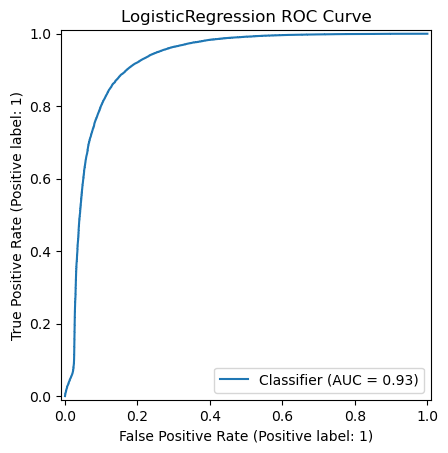


Model: RandomForest


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:    0.2s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   6 out of  10 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=8)]: Done  10 out of  10 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   6 out of  10 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=8)]: Done  10 out of  10 | elapsed:    0.0s finished


Test Accuracy: 0.7022528086583142
Test Precision: 0.6626794258373205
Test Recall: 0.8919609149455918
Test F1: 0.760412722453616
Test ROC AUC: 0.8451736882828892
Confusion matrix:
 [[11718 12267]
 [ 2919 24099]]


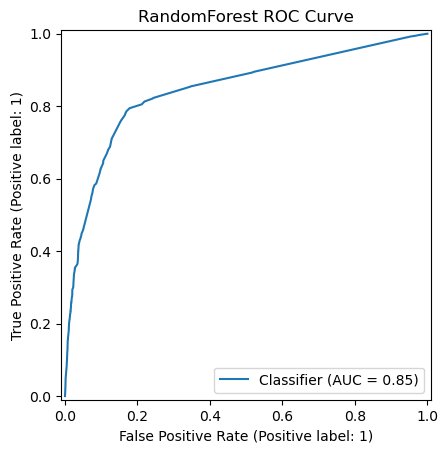


Model: XGBoost
Test Accuracy: 0.8769092014195243
Test Precision: 0.8590222960808752
Test Recall: 0.918350729143534
Test F1: 0.8876963257128546
Test ROC AUC: 0.9333766448183395
Confusion matrix:
 [[19913  4072]
 [ 2206 24812]]


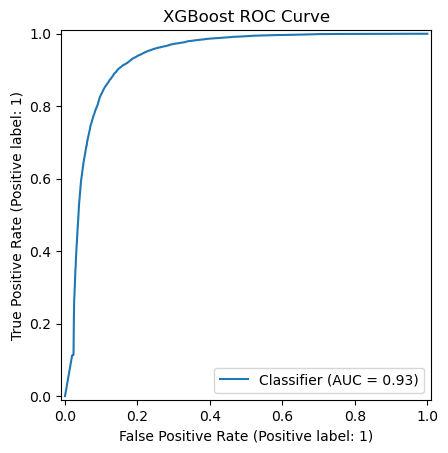

In [2]:
import os
import json
import numpy as np
import pandas as pd
from tqdm import tqdm

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# =========================================================
# SETTINGS
# =========================================================
SEED = 42
np.random.seed(SEED)

TEST_FRAC_PER_USER = 0.2
CV_SPLITS = 3

file = r"D:\bachelor_project\ml\network_feat\network_feat_small.csv"

# =========================================================
# LOAD DATA
# =========================================================
df = pd.read_csv(file, sep=",", quotechar='"')
print("Original shape:", df.shape)
print("Unique users:", df["steamid"].nunique())
print("Unique games:", df["appid"].nunique())

# =========================================================
# USER & GAME FEATURES
# =========================================================
users_features = df[['steamid', 'country', 'total_games_owned',
                     'total_playtime_minutes', 'median_playtime_minutes',
                     'unique_genres_played', 'friend_count', 'user_count']].drop_duplicates('steamid')

games_features = df[['appid', 'name', 'genres', 'developer', 'publisher', 'platforms',
                     'release_date', 'game_total_playtime_minutes'] + 
                     [c for c in df.columns if c.startswith('game_emb_')]].drop_duplicates('appid')

positives = df[['steamid', 'appid']].drop_duplicates()
positives["owned"] = 1

all_games = np.array(sorted(df["appid"].unique()))
user_owned = positives.groupby("steamid")["appid"].apply(lambda s: np.array(s.values)).to_dict()

# =========================================================
# BUILD TRAIN / TEST WITH NEGATIVE SAMPLING
# =========================================================
train_pairs, test_pairs = [], []

print("Building per-user train/test with negative sampling...")
for user, owned_games in tqdm(user_owned.items(), desc="Users"):

    owned_games = np.unique(owned_games)

    if len(owned_games) < 2:
        pos_train = owned_games
        pos_test = np.array([], dtype=owned_games.dtype)
    else:
        rng = np.random.default_rng(SEED + int(user) % 100000)
        shuffled = owned_games.copy()
        rng.shuffle(shuffled)
        n_test = max(1, int(np.ceil(TEST_FRAC_PER_USER * len(shuffled))))
        pos_test = shuffled[:n_test]
        pos_train = shuffled[n_test:]

    train_pairs.extend([(user, g, 1) for g in pos_train])
    test_pairs.extend([(user, g, 1) for g in pos_test])

    not_owned = all_games[~np.isin(all_games, owned_games)]
    if len(not_owned) == 0:
        continue

    n_neg_train = len(pos_train)
    n_neg_test = len(pos_test)

    # sample negative test first
    if n_neg_test > 0:
        replace_test = len(not_owned) < n_neg_test
        neg_test = np.random.choice(not_owned, size=n_neg_test, replace=replace_test)
        neg_test_set = set(map(int, neg_test))
    else:
        neg_test = np.array([], dtype=not_owned.dtype)
        neg_test_set = set()

    train_pool = np.array([g for g in not_owned if int(g) not in neg_test_set])
    if len(train_pool) == 0:
        train_pool = not_owned

    if n_neg_train > 0:
        replace_train = len(train_pool) < n_neg_train
        neg_train = np.random.choice(train_pool, size=n_neg_train, replace=replace_train)
    else:
        neg_train = np.array([], dtype=not_owned.dtype)

    train_pairs.extend([(user, g, 0) for g in neg_train])
    test_pairs.extend([(user, g, 0) for g in neg_test])

train_df = pd.DataFrame(train_pairs, columns=["steamid","appid","owned"])
test_df  = pd.DataFrame(test_pairs, columns=["steamid","appid","owned"])

train_df = train_df.drop_duplicates(["steamid","appid"]).reset_index(drop=True)
test_df  = test_df.drop_duplicates(["steamid","appid"]).reset_index(drop=True)

# =========================================================
# ATTACH FEATURES
# =========================================================
train_all = train_df.merge(users_features, on="steamid", how="left")
train_all = train_all.merge(games_features, on="appid", how="left")

test_all = test_df.merge(users_features, on="steamid", how="left")
test_all = test_all.merge(games_features, on="appid", how="left")

# =========================================================
# FEATURE SET
# =========================================================
numeric_features = [
    "total_games_owned","total_playtime_minutes","median_playtime_minutes",
    "unique_genres_played","friend_count","user_count","game_total_playtime_minutes"
]

categorical_features = [
    "country","developer","publisher","platforms","genres"
]

# Add all embedding columns
embedding_features = [c for c in df.columns if c.startswith("game_emb_")]
numeric_features += embedding_features

target = "owned"

X_train = train_all[numeric_features + categorical_features].copy()
y_train = train_all[target].astype(int)

X_test  = test_all[numeric_features + categorical_features].copy()
y_test  = test_all[target].astype(int)

# =========================================================
# MISSING VALUE POLICY
# =========================================================
missing_flags = []

for c in numeric_features:
    flag = c + "_is_missing"
    missing_flags.append(flag)

    X_train[flag] = X_train[c].isna().astype("int8")
    X_test[flag]  = X_test[c].isna().astype("int8")

    med = float(X_train[c].median(skipna=True))
    X_train[c] = X_train[c].fillna(med).astype(np.float32)
    X_test[c]  = X_test[c].fillna(med).astype(np.float32)

for c in categorical_features:
    X_train[c] = X_train[c].fillna("MISSING").astype(str)
    X_test[c]  = X_test[c].fillna("MISSING").astype(str)

# =========================================================
# CROSS-VALIDATION SETUP
# =========================================================
cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=SEED)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("miss", "passthrough", missing_flags),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop"
)

# =========================================================
# MODELS
# =========================================================
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=SEED, n_jobs=-1),
    "RandomForest": RandomForestClassifier(n_estimators=10, max_depth=5, min_samples_leaf=2, random_state=SEED, n_jobs=-1, verbose=1),
    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=SEED,
        n_estimators=10,
        learning_rate=0.05,
        tree_method="hist",
        n_jobs=-1,
        verbosity=1
    )
}

# =========================================================
# TRAIN + EVALUATION
# =========================================================
for name, model in models.items():
    print(f"\n==============================\nModel: {name}\n==============================")

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    print("Test Accuracy:", accuracy_score(y_test, y_pred))
    print("Test Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Test Recall:", recall_score(y_test, y_pred, zero_division=0))
    print("Test F1:", f1_score(y_test, y_pred, zero_division=0))
    print("Test ROC AUC:", roc_auc_score(y_test, y_proba))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

    # Plot ROC curve
    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title(f"{name} ROC Curve")
    plt.show()

## NN ML for baseline

In [2]:
import os
import json
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, auc
)
from sklearn.model_selection import StratifiedKFold

# =========================================================
# SETTINGS
# =========================================================
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TEST_FRAC_PER_USER = 0.2
BATCH_SIZE = 128
EPOCHS = 10
LR = 0.01

file = r"C:\Users\jkgas\OneDrive\Desktop\data_science\Spring_2026\bachelor_project\data\baseline\baseline_small.csv"

# =========================================================
# LOAD DATA
# =========================================================
df = pd.read_csv(file, sep=",", quotechar='"')
print("Original shape:", df.shape)
print("Unique users:", df["steamid"].nunique())
print("Unique games:", df["appid"].nunique())

# =========================================================
# USER & GAME FEATURES
# =========================================================
users_features = df[['steamid', 'country', 'total_games_owned',
                     'total_playtime_minutes', 'median_playtime_minutes',
                     'unique_genres_played', 'user_count']].drop_duplicates('steamid')

games_features = df[['appid', 'name', 'genres', 'developer',
                     'publisher', 'platforms', 'release_date',
                     'game_total_playtime_minutes']].drop_duplicates('appid')

positives = df[['steamid', 'appid']].drop_duplicates()
positives["owned"] = 1
all_games = np.array(sorted(df["appid"].unique()))
user_owned = positives.groupby("steamid")["appid"].apply(lambda s: np.array(s.values)).to_dict()

# =========================================================
# BUILD TRAIN / TEST WITH NEGATIVE SAMPLING
# =========================================================
train_pairs, test_pairs = [], []

print("Building per-user train/test with negative sampling...")
for user, owned_games in tqdm(user_owned.items(), desc="Users"):
    owned_games = np.unique(owned_games)
    if len(owned_games) < 2:
        pos_train = owned_games
        pos_test = np.array([], dtype=owned_games.dtype)
    else:
        rng = np.random.default_rng(SEED + int(user) % 100000)
        shuffled = owned_games.copy()
        rng.shuffle(shuffled)
        n_test = max(1, int(np.ceil(TEST_FRAC_PER_USER * len(shuffled))))
        pos_test = shuffled[:n_test]
        pos_train = shuffled[n_test:]
    
    train_pairs.extend([(user, g, 1) for g in pos_train])
    test_pairs.extend([(user, g, 1) for g in pos_test])

    not_owned = all_games[~np.isin(all_games, owned_games)]
    if len(not_owned) == 0:
        continue

    n_neg_train = len(pos_train)
    n_neg_test = len(pos_test)

    # sample negatives
    neg_test = np.random.choice(not_owned, size=n_neg_test, replace=len(not_owned) < n_neg_test) if n_neg_test > 0 else []
    neg_test_set = set(map(int, neg_test))
    train_pool = np.array([g for g in not_owned if int(g) not in neg_test_set])
    if len(train_pool) == 0:
        train_pool = not_owned
    neg_train = np.random.choice(train_pool, size=n_neg_train, replace=len(train_pool) < n_neg_train) if n_neg_train > 0 else []

    train_pairs.extend([(user, g, 0) for g in neg_train])
    test_pairs.extend([(user, g, 0) for g in neg_test])

train_df = pd.DataFrame(train_pairs, columns=["steamid","appid","owned"]).drop_duplicates(["steamid","appid"]).reset_index(drop=True)
test_df  = pd.DataFrame(test_pairs, columns=["steamid","appid","owned"]).drop_duplicates(["steamid","appid"]).reset_index(drop=True)

# =========================================================
# ATTACH FEATURES
# =========================================================
train_all = train_df.merge(users_features, on="steamid", how="left").merge(games_features, on="appid", how="left")
test_all  = test_df.merge(users_features, on="steamid", how="left").merge(games_features, on="appid", how="left")

# =========================================================
# FEATURE SET
# =========================================================
numeric_features = [
    "total_games_owned","total_playtime_minutes","median_playtime_minutes",
    "unique_genres_played","user_count","game_total_playtime_minutes"
]

categorical_features = [
    "country","developer","publisher","platforms","genres"
]

target = "owned"

X_train = train_all[numeric_features + categorical_features].copy()
y_train = train_all[target].astype(int)
X_test  = test_all[numeric_features + categorical_features].copy()
y_test  = test_all[target].astype(int)

# =========================================================
# MISSING VALUE HANDLING
# =========================================================
missing_flags = []
for c in numeric_features:
    flag = c + "_is_missing"
    missing_flags.append(flag)
    X_train[flag] = X_train[c].isna().astype("int8")
    X_test[flag]  = X_test[c].isna().astype("int8")
    med = X_train[c].median(skipna=True)
    X_train[c] = X_train[c].fillna(med).astype(np.float32)
    X_test[c]  = X_test[c].fillna(med).astype(np.float32)

for c in categorical_features:
    X_train[c] = X_train[c].fillna("MISSING").astype(str)
    X_test[c]  = X_test[c].fillna("MISSING").astype(str)

# =========================================================
# PREPROCESSING
# =========================================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("miss", "passthrough", missing_flags),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_proc.todense() if hasattr(X_train_proc, "todense") else X_train_proc, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_proc.todense() if hasattr(X_test_proc, "todense") else X_test_proc, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=os.cpu_count())

# =========================================================
# SIMPLE NEURAL NETWORK
# =========================================================
input_size = X_train_tensor.shape[1]
model = nn.Sequential(
    nn.Linear(input_size, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Sigmoid()
).to(DEVICE)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# =========================================================
# TRAINING LOOP WITH PROGRESS BAR
# =========================================================
train_losses = []
for epoch in range(EPOCHS):
    model.train()
    epoch_losses = []
    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        y_pred = model(xb)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
    avg_loss = np.mean(epoch_losses)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1} avg loss: {avg_loss:.4f}")

# =========================================================
# PLOTS
# =========================================================
# Learning curve
plt.figure(figsize=(8,5))
plt.plot(range(1,EPOCHS+1), train_losses, marker='o')
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# =========================================================
# EVALUATION + ROC CURVE
# =========================================================
model.eval()
with torch.no_grad():
    y_pred_probs = model(X_test_tensor.to(DEVICE)).cpu().numpy()
    y_pred_labels = (y_pred_probs > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_labels))
print("Precision:", precision_score(y_test, y_pred_labels))
print("Recall:", recall_score(y_test, y_pred_labels))
print("F1:", f1_score(y_test, y_pred_labels))
print("ROC AUC:", roc_auc_score(y_test, y_pred_probs))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_labels))

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Original shape: (133207, 15)
Unique users: 1000
Unique games: 18832
Building per-user train/test with negative sampling...


Users: 100%|███████████████████████████████████████████████████████████████████████| 1000/1000 [00:10<00:00, 99.64it/s]


RuntimeError: [enforce fail at alloc_cpu.cpp:114] data. DefaultCPUAllocator: not enough memory: you tried to allocate 18700295620 bytes.

## NN ML for model with network features

In [4]:
import os
import json
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, auc
)
from sklearn.model_selection import StratifiedKFold

# =========================================================
# SETTINGS
# =========================================================
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TEST_FRAC_PER_USER = 0.2
BATCH_SIZE = 128
EPOCHS = 10
LR = 0.01

file = r"D:\bachelor_project\ml\network_feat\network_feat_small.csv"

# =========================================================
# LOAD DATA
# =========================================================
df = pd.read_csv(file, sep=",", quotechar='"')
print("Original shape:", df.shape)
print("Unique users:", df["steamid"].nunique())
print("Unique games:", df["appid"].nunique())

# =========================================================
# DETECT GAME EMBEDDINGS
# =========================================================
embedding_features = [c for c in df.columns if c.startswith("game_emb_")]
print(f"Detected {len(embedding_features)} embedding features")

# =========================================================
# USER & GAME FEATURES
# =========================================================
users_features = df[['steamid', 'country', 'total_games_owned',
                     'total_playtime_minutes', 'median_playtime_minutes',
                     'unique_genres_played', 'friend_count', 'user_count']].drop_duplicates('steamid')

games_features = df[
    ['appid', 'name', 'genres', 'developer',
     'publisher', 'platforms', 'release_date',
     'game_total_playtime_minutes']
    + embedding_features
].drop_duplicates('appid')

positives = df[['steamid', 'appid']].drop_duplicates()
positives["owned"] = 1
all_games = np.array(sorted(df["appid"].unique()))
user_owned = positives.groupby("steamid")["appid"].apply(lambda s: np.array(s.values)).to_dict()

# =========================================================
# BUILD TRAIN / TEST WITH NEGATIVE SAMPLING
# =========================================================
train_pairs, test_pairs = [], []

print("Building per-user train/test with negative sampling...")
for user, owned_games in tqdm(user_owned.items(), desc="Users"):
    owned_games = np.unique(owned_games)
    if len(owned_games) < 2:
        pos_train = owned_games
        pos_test = np.array([], dtype=owned_games.dtype)
    else:
        rng = np.random.default_rng(SEED + int(user) % 100000)
        shuffled = owned_games.copy()
        rng.shuffle(shuffled)
        n_test = max(1, int(np.ceil(TEST_FRAC_PER_USER * len(shuffled))))
        pos_test = shuffled[:n_test]
        pos_train = shuffled[n_test:]
    
    train_pairs.extend([(user, g, 1) for g in pos_train])
    test_pairs.extend([(user, g, 1) for g in pos_test])

    not_owned = all_games[~np.isin(all_games, owned_games)]
    if len(not_owned) == 0:
        continue

    n_neg_train = len(pos_train)
    n_neg_test = len(pos_test)

    # sample negatives
    neg_test = np.random.choice(not_owned, size=n_neg_test, replace=len(not_owned) < n_neg_test) if n_neg_test > 0 else []
    neg_test_set = set(map(int, neg_test))
    train_pool = np.array([g for g in not_owned if int(g) not in neg_test_set])
    if len(train_pool) == 0:
        train_pool = not_owned
    neg_train = np.random.choice(train_pool, size=n_neg_train, replace=len(train_pool) < n_neg_train) if n_neg_train > 0 else []

    train_pairs.extend([(user, g, 0) for g in neg_train])
    test_pairs.extend([(user, g, 0) for g in neg_test])

train_df = pd.DataFrame(train_pairs, columns=["steamid","appid","owned"]).drop_duplicates(["steamid","appid"]).reset_index(drop=True)
test_df  = pd.DataFrame(test_pairs, columns=["steamid","appid","owned"]).drop_duplicates(["steamid","appid"]).reset_index(drop=True)

# =========================================================
# ATTACH FEATURES
# =========================================================
train_all = train_df.merge(users_features, on="steamid", how="left").merge(games_features, on="appid", how="left")
test_all  = test_df.merge(users_features, on="steamid", how="left").merge(games_features, on="appid", how="left")

# =========================================================
# FEATURE SET
# =========================================================
numeric_features = [
    "total_games_owned",
    "total_playtime_minutes",
    "median_playtime_minutes",
    "unique_genres_played",
    "friend_count",
    "user_count",
    "game_total_playtime_minutes"
] + embedding_features

categorical_features = [
    "country","developer","publisher","platforms","genres"
]

target = "owned"

X_train = train_all[numeric_features + categorical_features].copy()
y_train = train_all[target].astype(int)
X_test  = test_all[numeric_features + categorical_features].copy()
y_test  = test_all[target].astype(int)

# =========================================================
# MISSING VALUE HANDLING
# =========================================================
missing_flags = []
for c in numeric_features:
    flag = c + "_is_missing"
    missing_flags.append(flag)
    X_train[flag] = X_train[c].isna().astype("int8")
    X_test[flag]  = X_test[c].isna().astype("int8")
    med = X_train[c].median(skipna=True)
    X_train[c] = X_train[c].fillna(med).astype(np.float32)
    X_test[c]  = X_test[c].fillna(med).astype(np.float32)

for c in categorical_features:
    X_train[c] = X_train[c].fillna("MISSING").astype(str)
    X_test[c]  = X_test[c].fillna("MISSING").astype(str)

# =========================================================
# PREPROCESSING
# =========================================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("miss", "passthrough", missing_flags),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_proc.todense() if hasattr(X_train_proc, "todense") else X_train_proc, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_proc.todense() if hasattr(X_test_proc, "todense") else X_test_proc, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=os.cpu_count())

# =========================================================
# SIMPLE NEURAL NETWORK
# =========================================================
input_size = X_train_tensor.shape[1]
model = nn.Sequential(
    nn.Linear(input_size, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Sigmoid()
).to(DEVICE)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# =========================================================
# TRAINING LOOP WITH PROGRESS BAR
# =========================================================
train_losses = []
for epoch in range(EPOCHS):
    model.train()
    epoch_losses = []
    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        y_pred = model(xb)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
    avg_loss = np.mean(epoch_losses)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1} avg loss: {avg_loss:.4f}")

# =========================================================
# PLOTS
# =========================================================
# Learning curve
plt.figure(figsize=(8,5))
plt.plot(range(1,EPOCHS+1), train_losses, marker='o')
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# =========================================================
# EVALUATION + ROC CURVE
# =========================================================
model.eval()
with torch.no_grad():
    y_pred_probs = model(X_test_tensor.to(DEVICE)).cpu().numpy()
    y_pred_labels = (y_pred_probs > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_labels))
print("Precision:", precision_score(y_test, y_pred_labels))
print("Recall:", recall_score(y_test, y_pred_labels))
print("F1:", f1_score(y_test, y_pred_labels))
print("ROC AUC:", roc_auc_score(y_test, y_pred_probs))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_labels))

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Original shape: (133207, 45)
Unique users: 1000
Unique games: 18832
Detected 29 embedding features
Building per-user train/test with negative sampling...


Users: 100%|███████████████████████████████████████████████████████████████████████| 1000/1000 [00:18<00:00, 54.34it/s]


RuntimeError: [enforce fail at alloc_cpu.cpp:114] data. DefaultCPUAllocator: not enough memory: you tried to allocate 18747768340 bytes.